In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
import os

notebook_path = os.getcwd()
print(notebook_path)

/scratch/ff2183/Causality-Simple-Models/L96-Stochastic/L96_Stochastic_Fj/Share/score_matching


In [3]:
def to_zero_mean_unit_variance(x,mean_i,std_i):
    
    # Input: 
    # np.shape(x) = (Dimension, Time)
    # sigma of each x[i]
    # Output: x_std, where each x[i] is zero mean and unit variance
    
    # For each component of x_t, divide by its sigma
    x_t_std = x.copy()
    for i in range(len(std_i)):
        x_t_std[i] = (x[i]-mean_i[i])/std_i[i]
        
    return x_t_std

## Load data

In [4]:
x_t_all = np.load('../../RK4/results/L96_orbit.npy').T
x_t_all.shape

(20, 1000000)

In [5]:
# Inputs

# ~95% training
x_t_TRAIN = x_t_all[:,0:900000].copy()
# Consider years 500-600 for testing
x_t_TESTING = x_t_all[:,900000:].copy()

# Mean and standard deviation of the training set
train_mean_i = np.mean(x_t_TRAIN,1)
train_std_i = np.std(x_t_TRAIN,1)

np.save('./results/train_mean_i.npy',train_mean_i)
np.save('./results/train_std_i.npy',train_std_i)

# Standardize the two
x_t_TRAIN_std = to_zero_mean_unit_variance(x_t_TRAIN,train_mean_i,train_std_i)
x_t_TESTING_std = to_zero_mean_unit_variance(x_t_TESTING,train_mean_i,train_std_i)

np.save('./results/x_t_TRAIN_std.npy',x_t_TRAIN_std)
np.save('./results/x_t_TESTING_std.npy',x_t_TESTING_std)

In [6]:
x_t_TRAIN.shape

(20, 900000)

In [7]:
x_t_TESTING.shape

(20, 100000)

In [8]:
del x_t_all

## Step (b): score matching by Hyvaarinen

### Set the NN

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

In [10]:
class ScoreNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ScoreNet, self).__init__()
        #self.linear = nn.Linear(input_dim, input_dim,bias = False)  # Linear operator L
        self.nonlinear = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )  # Nonlinear operator N

    def forward(self, x):
        #linear_part = self.linear(x)
        nonlinear_part = self.nonlinear(x)
        return nonlinear_part

# =====================================================
# 2. GPU setup
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
print("Using device:", device)

# Initialize the model
input_dim = 20  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units. It was 500
output_dim = 20  # Dimensionality of the output
model = ScoreNet(input_dim, hidden_dim).to(device)#.double() # Equivalent to .to(torch.float64)

Using device: cuda


In [11]:
### Hyvarinen loss with Hutchinson divergence estimator
import torch.autograd as autograd

def hyvarinen_loss(model, x, n_hutch=1):
    """
    x: tensor [B, d]
    returns scalar loss (mean over batch)
    """
    x = x.detach().requires_grad_(True)   # keep dtype/device from input
    s = model(x)                          # [B, d]
    sq = 0.5 * (s.pow(2).sum(dim=1))      # [B]

    B, d = x.shape
    div_est = torch.zeros(B, device=x.device, dtype=x.dtype)
    for _ in range(n_hutch):
        # Rademacher probe ±1
        v = (torch.randint(0, 2, size=(B, d), device=x.device).to(x.dtype) * 2.0 - 1.0)
        dot = (s * v).sum(dim=1)   
        grad_dot = autograd.grad(dot.sum(), x, create_graph=True)[0]
        div_est = div_est + (grad_dot * v).sum(dim=1)
    div_est = div_est / float(n_hutch)

    loss = (sq + div_est).mean()
    return loss

def exact_hyvarinen_loss(model, x):
    """
    Computes the EXACT Score Matching loss using the full trace of the Jacobian.
    Only recommended when input dimensionality (d) is small (e.g., 20).
    """
    x = x.detach().requires_grad_(True)
    s = model(x)                        # [B, d]
    sq = 0.5 * (s.pow(2).sum(dim=1))    # [B]

    B, d = x.shape
    exact_div = torch.zeros(B, device=x.device, dtype=x.dtype)
    
    # Loop exactly 'd' times (20 times for your data)
    for i in range(d):
        # Create the standard basis vector (1 at index i, 0 everywhere else)
        v = torch.zeros_like(x)
        v[:, i] = 1.0
        
        # Extract the i-th output dimension
        dot = (s * v).sum(dim=1)   
        
        # Calculate the gradient of the i-th output with respect to the input
        grad_dot = autograd.grad(dot.sum(), x, create_graph=True)[0]
        
        # Accumulate the i-th diagonal element of the Jacobian
        exact_div = exact_div + grad_dot[:, i]

    loss = (sq + exact_div).mean()
    return loss

In [14]:
# Model and optimizer
#optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-6)#1e-6 0.0001 or 0.0005

## Train the model

In [12]:
### Convert data to PyTorch tensors

# TRAINING SET
x_t_tensor_TRAIN = torch.tensor(x_t_TRAIN_std.T, dtype=torch.float32, device=device)  # Shape: (1999, 101)
# TESTING SET
x_t_tensor_TEST = torch.tensor(x_t_TESTING_std.T, dtype=torch.float32, device=device)  # Shape: (1999, 101)

### Training the model

In [ ]:
%%time

import torch.optim.lr_scheduler as lr_scheduler

num_epochs = 6000
batch_size = 100000
n_hutch_train = 1
loss_value_training = []
loss_value_testing = []

# Initialize variables for tracking best model
best_loss = float('inf')  # Initialize with a very large value
best_model_state_dict = None

# Initialize Optimizer and Scheduler
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-6)

milestones = list(range(500, 6000, 200))

# Initialize MultiStepLR: gamma=0.5 halves the LR at each milestone. 
# (Change to 0.8 or 0.9 if the LR drops too fast over 3000 epochs)
scheduler = lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.5)

for epoch in range(num_epochs):
    
    print(f'Training epoch #{epoch}')

    ### Randomize training and testing data
    # Standard shuffling without replacement
    idx_train = torch.randperm(len(x_t_tensor_TRAIN))
    x_t_tensor_random_TRAIN = x_t_tensor_TRAIN[idx_train]

    idx_test = torch.randperm(len(x_t_tensor_TEST))
    x_t_tensor_random_TEST = x_t_tensor_TEST[idx_test]
    
    # ==========================================
    # TRAINING LOOP
    # ==========================================
    model.train()
    epoch_loss_train = 0.0
    num_batches_train = 0

    for i in range(0, len(x_t_tensor_random_TRAIN), batch_size):
        x_batch_TRAIN = x_t_tensor_random_TRAIN[i:i+batch_size]

        loss = exact_hyvarinen_loss(model, x_batch_TRAIN)
        
        epoch_loss_train += loss.item()
        num_batches_train += 1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    avg_loss_train = epoch_loss_train/num_batches_train
    loss_value_training.append(avg_loss_train)
    
    # ==========================================
    # TESTING LOOP
    # ==========================================
    model.eval()
    epoch_loss_test = 0.0
    num_batches_test = 0

    # NOTE: torch.no_grad() is intentionally excluded here because 
    # exact_hyvarinen_loss requires input gradients for the Jacobian trace.
    for i in range(0, len(x_t_tensor_random_TEST), batch_size):
        x_batch_TEST = x_t_tensor_random_TEST[i:i+batch_size]
        loss = exact_hyvarinen_loss(model, x_batch_TEST)

        epoch_loss_test += loss.item()
        num_batches_test += 1

    avg_loss_test = epoch_loss_test / num_batches_test
    loss_value_testing.append(avg_loss_test)
    
    # ==========================================
    # STEP THE SCHEDULER
    # ==========================================
    scheduler.step()  
    
    # Print the LR only when it changes (at milestones)
    if epoch in milestones:
        print(f">>> LR decayed to {scheduler.get_last_lr()[0]:.6f} at epoch {epoch}")
    
    # ==========================================
    # SAVE BEST MODEL
    # ==========================================
    if avg_loss_test < best_loss:
        best_loss = avg_loss_test
        best_model_state_dict = model.state_dict().copy()  # Deep copy the weights
        print(f"New best model found at epoch {epoch} with validation loss: {best_loss:.4f}")

# After all epochs, save the best model
if best_model_state_dict is not None:
    torch.save(best_model_state_dict, './results/best_model.pth')
    print(f"Best model saved with validation loss: {best_loss:.4f}")

Training epoch #0
New best model found at epoch 0 with validation loss: -9.0392
Training epoch #1
New best model found at epoch 1 with validation loss: -10.5170
Training epoch #2
New best model found at epoch 2 with validation loss: -11.4415
Training epoch #3
New best model found at epoch 3 with validation loss: -11.9790
Training epoch #4
New best model found at epoch 4 with validation loss: -12.3014
Training epoch #5
New best model found at epoch 5 with validation loss: -12.5314
Training epoch #6
New best model found at epoch 6 with validation loss: -12.7021
Training epoch #7
New best model found at epoch 7 with validation loss: -12.8534
Training epoch #8
New best model found at epoch 8 with validation loss: -13.0019
Training epoch #9
New best model found at epoch 9 with validation loss: -13.1812
Training epoch #10
New best model found at epoch 10 with validation loss: -13.3881
Training epoch #11
New best model found at epoch 11 with validation loss: -13.6140
Training epoch #12
New be

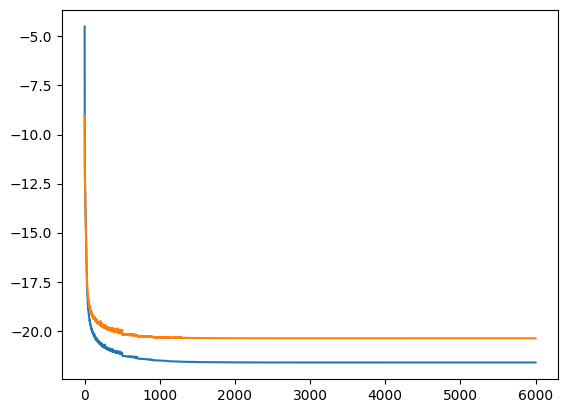

In [16]:
plt.plot(loss_value_training[:])
plt.plot(loss_value_testing[:])

In [17]:
np.save('./results/loss_value_training.npy',loss_value_training)
np.save('./results/loss_value_testing.npy',loss_value_testing)

## Apply

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

In [24]:
# Load data
x_t_all = np.load('../../RK4/results/L96_orbit.npy').T[:,:1000000]
x_t_all.shape
train_mean_i = np.load('./results/train_mean_i.npy')  # shape (3,)
train_std_i = np.load('./results/train_std_i.npy')    # shape (3,)

In [25]:
# Standardize
x_t_std = (x_t_all - train_mean_i[:, None]) / train_std_i[:, None]  # shape (3, T)

# Convert to tensor-friendly orientation
x_t_std = x_t_std.T  # shape (T, 3)

In [26]:
class ScoreNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ScoreNet, self).__init__()
        #self.linear = nn.Linear(input_dim, input_dim,bias = False)  # Linear operator L
        self.nonlinear = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )  # Nonlinear operator N

    def forward(self, x):
        #linear_part = self.linear(x)
        nonlinear_part = self.nonlinear(x)
        return nonlinear_part

# Choose the same device as used during training (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
print("Using device:", device)

# Initialize the model
input_dim = 20  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units (Note: maybe try hidden_dim > input_dim)
output_dim = 20  # Dimensionality of the output
model = ScoreNet(input_dim, hidden_dim).to(device)  # Equivalent to .to(torch.float64)
model.load_state_dict(torch.load('./results/best_model.pth'))

model.eval()

Using device: cuda


ScoreNet(
  (nonlinear): Sequential(
    (0): Linear(in_features=20, out_features=100, bias=True)
    (1): SiLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): SiLU()
    (4): Linear(in_features=100, out_features=20, bias=True)
  )
)

In [27]:
# Convert once to torch tensor
x_t_std = torch.from_numpy(x_t_std).to(torch.float32).to(device)

chunk_size = 200_000  # adjust to fit memory
scores = np.zeros_like(x_t_std.cpu().numpy())  # make sure you have a NumPy array ready

with torch.no_grad():
    for start in range(0, x_t_std.shape[0], chunk_size):
        end = min(start + chunk_size, x_t_std.shape[0])
        x_chunk = x_t_std[start:end]  # already on device
        scores[start:end] = model(x_chunk).cpu().numpy()  # bring back to NumPy

# Save
np.save('./results/scores_all.npy', scores)

# Convert scores from standardized space
scores_orig = scores / train_std_i[None, :]  # elementwise divide
np.save('./results/scores_all_orig.npy', scores_orig)

In [28]:
scores_orig.shape

(1000000, 20)

# Response at t = 0 == I?

In [29]:
x_t_all = np.load('../../RK4/results/L96_orbit.npy')[:1000000]
score = np.load('./results/scores_all_orig.npy').T

In [30]:
x_t_all.shape

(1000000, 20)

In [31]:
score.shape

(20, 1000000)

In [32]:
response_matrix_t0 = []

n_time = len(x_t_all)

R_0 = -np.dot(x_t_all.T,score.T)/(n_time)

## Corrected score: mean

In [34]:
#x_t_all = np.load('../RK4/results/L96_orbit.npy')[:10000001]
#x_t_all.shape
score = np.load('./results/scores_all_orig.npy').T

In [35]:
x_t_all.shape

(1000000, 20)

In [36]:
score.shape

(20, 1000000)

In [37]:
response_matrix_t0 = []

x_t = x_t_all
n_time = len(x_t_all)

R_0 = -np.dot(x_t.T,score.T)/(n_time)

In [38]:
error_matrix = - (R_0 - np.identity(20))
error_matrix;

In [39]:
corrected_score = np.dot(score.T, np.linalg.inv(np.identity(20) - error_matrix))

In [40]:
del score

In [41]:
### Check

n_time = len(x_t_all)

R_0 = -np.dot(x_t_all.T,corrected_score)/(n_time)

R_0;

In [42]:
np.save('./results/corrected_score.npy',corrected_score)

# FDT: mean after correction

In [55]:
#x_t_all = np.load('../RK4/results/L96_orbit.npy')[:10000001]
corrected_score = np.load('./results/corrected_score.npy')

In [56]:
x_t_all.shape

(1000000, 20)

In [57]:
tau_max = 3

response_matrix_score_nn = []

n_time = len(x_t_all)

for tau in range(tau_max):
    print('tau = '+str(tau))
    orbit1 = x_t_all[tau:]  # remove the FIRST tau elements
    orbit2 = corrected_score[:n_time-tau]  # remove the LAST tau elements
    ########## Compute the response matrix
    response_matrix_score_nn.append(-np.dot(orbit1.T,orbit2)/(n_time))

response_matrix_score_nn = np.array(response_matrix_score_nn)

tau = 0
tau = 1
tau = 2


In [58]:
np.save('./results_responses/FDT_mean-Generative.npy',response_matrix_score_nn)

## Causal links

In [59]:
response_matrix_score_nn = np.load('./results_responses/FDT_mean-Generative.npy')

In [61]:
x_t_all = x_t_all.T

In [62]:
sigmas = np.std(x_t_all,1)

In [63]:
sigmas

array([7.55916783, 7.26217886, 8.0875473 , 8.32851403, 7.83075971,
       7.87574883, 7.39450564, 7.07075761, 7.11464192, 6.78286933,
       7.17509439, 7.21396519, 7.58000363, 7.93035865, 7.94886665,
       7.90835899, 7.97274008, 7.68849118, 6.98720892, 7.14856951])

In [64]:
del x_t_all

In [65]:
np.save('./results/SIGMAS.npy',sigmas)

### Compute causal links

In [66]:
response_matrix_score_nn = np.load('./results_responses/FDT_mean-Generative.npy')
sigmas = np.load('./results/SIGMAS.npy')

In [67]:
# Standardized R
responses_std = np.zeros_like(response_matrix_score_nn)

for j in range(20):
    for k in range(20):
        responses_std[:,k,j] = response_matrix_score_nn[:,k,j]
        
# As an option here we can add standardization 
# (useful if we have data expressed in PC with different scales)
# This would be
'''
for j in range(20):
    for k in range(20):
        responses_std[:,k,j] = (sigmas[j]/sigmas[k]) response_matrix_score_nn[:,k,j]
'''

In [68]:
R_1 = responses_std[1]

In [69]:
# Let's remove the diagonal from the analysis (as we expect that each mode drives at least itself)

# Create a mask that is False on the diagonal, True elsewhere
mask = ~np.eye(R_1.shape[0], dtype=bool)
R_1_flat = R_1[mask]

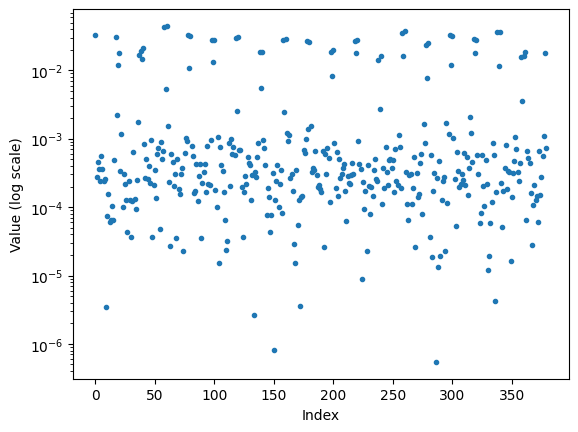

In [70]:
# Plotting in log value
plt.plot(np.abs(R_1_flat),'.')
plt.yscale("log")   # logarithmic y-axis
plt.xlabel("Index")
plt.ylabel("Value (log scale)")
plt.show()

## K-means for distinguishing direct causal links

In [71]:
x = np.log(np.abs(R_1_flat))
x.shape

(380,)

In [72]:
from sklearn.cluster import KMeans

# Reshape to 2D (required by sklearn)
X = x.reshape(-1, 1)
# KMeans with 2 clusters
kmeans = kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    init='k-means++',
    n_init=10
).fit(X)

# Cluster labels for each point
labels = kmeans.labels_
# Cluster centers
centers = kmeans.cluster_centers_.flatten()

print("Cluster labels:", labels)
print("Cluster centers:", centers)

Cluster labels: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0]
Cluster centers: [-8.41123442 -4.08977128]


Text(0.5, 1.0, '$R^{\\mu}_{k,j}(dt)$: Score Matching. K-means')

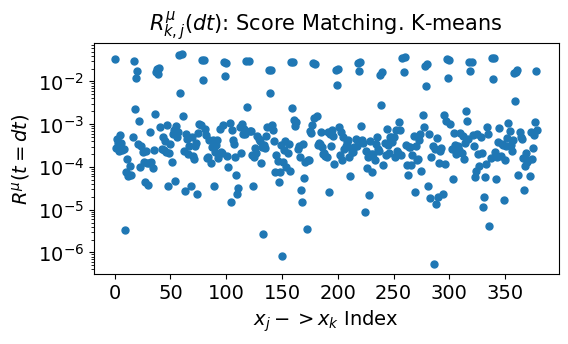

In [73]:
fig = plt.figure(figsize=(6,3))

fontsize_title = 15

ax = plt.subplot(111)

x = np.abs(R_1_flat)
#plt.plot(np.abs(R_1_flat_SM),'.',markersize=7)
plt.plot(x, '.', markersize=10)

#plt.legend(fontsize = 15)
plt.yscale("log")
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

#plt.ylim(4*10**-6,0.01)

plt.xlabel(r'$x_j -> x_k$ Index',fontsize = 14)
plt.ylabel(r'$R^{\mu}(t = dt)$',fontsize = 14)
        
plt.title(r'$R^{\mu}_{k,j}(dt)$: Score Matching. K-means', fontsize=fontsize_title)
#plt.title('(a)', loc = 'left', fontsize=fontsize_title)
#fig.savefig('./links_SM_NOT_clustered.pdf',bbox_inches='tight')

In [ ]:
fig = plt.figure(figsize=(6,3))

fontsize_title = 15

ax = plt.subplot(111)

x = np.abs(R_1_flat)
#plt.plot(np.abs(R_1_flat_SM),'.',markersize=7)
plt.plot(np.where(labels == 0)[0], x[labels == 0], '.', color='black', markersize=10)
plt.plot(np.where(labels == 1)[0], x[labels == 1], '.', color='blue', markersize=10)


plt.legend(loc = 'upper right',fontsize = 8)
plt.yscale("log")
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

#plt.ylim(4*10**-6,0.01)

plt.xlabel(r'$x_j -> x_k$ Index',fontsize = 14)
plt.ylabel(r'$R^{\mu}(t = dt)$',fontsize = 14)
        
plt.title(r'$R^{\mu}_{k,j}(dt)$: Score Matching. K-means', fontsize=fontsize_title)
#plt.title('(a)', loc = 'left', fontsize=fontsize_title)
#fig.savefig('./links_SM_clustered.pdf',bbox_inches='tight')

In [75]:
# Reconstruct adjacency matrix

# Adjacency matrix

# Iniatialize
Adj_m = np.eye(R_1.shape[0], dtype=int) 

# Mask for off-diagonal entries
mask = ~np.eye(Adj_m.shape[0], dtype=bool)
mask

# Consider off-diagonals
Adj_m_off_diag = Adj_m[mask]

In [76]:
# If the labels corresponding to the largest centroids are 
# labeled as 0
# Then
labels_new = labels 

# If the labels corresponding to the largest centroids are 
# labeled as 1
# Then
#labels_new = labels - 1
#labels_new[labels_new!=0] = 1

In [77]:
# Assign values to the off-diagonal
Adj_m_off_diag = labels_new

Adj_m[mask] = Adj_m_off_diag

In [78]:
test = Adj_m.flatten()
len(test[test==0])

321

In [79]:
np.save('./results/Adj_m.npy',Adj_m)

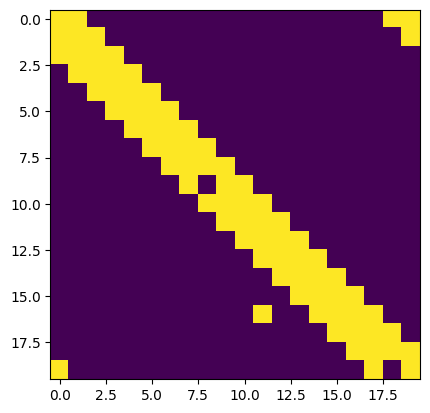

In [80]:
plt.imshow(Adj_m)

In [81]:
Adj_m

array([[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,